# Support Vector Machines (SVM)

Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>
MBA em Ciência de Dados, todos os direitos reservados<br>

<hr>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

Inicialmente, vamos ler os dados.

In [2]:
# se for usar o Colab, descomente
#from google.colab import drive
#drive.mount('/content/drive/')
#data = pd.read_csv('/content/drive/My Drive/dados/Vehicle.csv', header=(0))
#data = pd.read_csv('/content/drive/My Drive/dados/iris.csv', header=(0))

np.random.seed(10)
#data = pd.read_csv('data/Vehicle.csv', header=(0))
data = pd.read_csv('data/iris.csv', header=(0))

Fazemos a classificação usando o SVM.

In [3]:
# Separa as features (X) e a variável alvo (y)
X = data.drop(data.columns[-1], axis=1)
y = data[data.columns[-1]]

# Divide os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Cria e treina o modelo SVM
clf = svm.SVC(kernel='linear') # Você pode experimentar diferentes kernels ('rbf', 'poly', etc.)
clf.fit(X_train, y_train)

# Faz previsões no conjunto de teste
y_pred = clf.predict(X_test)

# Avalia o modelo
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred, average='weighted')) # weighted para lidar com classes múltiplas
print("Recall:", metrics.recall_score(y_test, y_pred, average='weighted'))
print("F1-score:", metrics.f1_score(y_test, y_pred, average='weighted'))
print(metrics.classification_report(y_test, y_pred)) #Relatório de classificação completo

Accuracy: 0.9777777777777777
Precision: 0.9796296296296295
Recall: 0.9777777777777777
F1-score: 0.9779434092477569
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        16
  versicolor       1.00      0.94      0.97        18
   virginica       0.92      1.00      0.96        11

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



Vamos escolher os hiperparâmetros do modelo.

In [4]:
# Define o espaço de hiperparâmetros para a busca em grade
param_grid = {
    'C': [0.1, 1, 10, 100],  # Parâmetro de regularização
    'gamma': [1, 0.1, 0.01, 0.001], # Define a influência de uma única instância de treinamento
    'kernel': ['linear', 'rbf', 'poly'] # Tipo de Kernel
}

# Cria o modelo SVM
svc = svm.SVC()

# Cria o objeto GridSearchCV
grid = GridSearchCV(svc, param_grid, refit=True, verbose=0) # refit=True para treinar o melhor modelo com todos os dados

# Treina o modelo com a busca em grade
grid.fit(X_train, y_train)

# Imprime os melhores hiperparâmetros encontrados
print(grid.best_params_)

# Avalia o melhor modelo no conjunto de teste
grid_predictions = grid.predict(X_test)

# Avalia o modelo
print("Accuracy:", metrics.accuracy_score(y_test, grid_predictions))
print("Precision:", metrics.precision_score(y_test, grid_predictions, average='weighted'))
print("Recall:", metrics.recall_score(y_test, grid_predictions, average='weighted'))
print("F1-score:", metrics.f1_score(y_test, grid_predictions, average='weighted'))
print(metrics.classification_report(y_test, grid_predictions))

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Accuracy: 0.9777777777777777
Precision: 0.9796296296296295
Recall: 0.9777777777777777
F1-score: 0.9779434092477569
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        16
  versicolor       1.00      0.94      0.97        18
   virginica       0.92      1.00      0.96        11

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



Podemos ainda realizar a regressão.

In [5]:
#from google.colab import drive
#drive.mount('/content/drive/')
#data = pd.read_csv('/content/drive/My Drive/dados/BostonHousing.csv', header=(0))

#data = pd.read_csv('data/Vehicle.csv', header=(0))
data = pd.read_csv('data/BostonHousing.csv', header=(0))

np.random.seed(10)
print("Número de linhas e colunas:", data.shape)
data.head(10)

Número de linhas e colunas: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


Faz a regressão e seleciona os hiperparâmetros.

In [6]:
# Separa as features (X) e a variável alvo (y)
X = data.drop(data.columns[-1], axis=1)
y = data[data.columns[-1]]

# Divide os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Define o espaço de hiperparâmetros para a busca em grade
param_grid = {
    'C': [0.1, 1, 10, 100],  # Parâmetro de regularização
    #'gamma': [1, 0.1, 0.01, 0.001], # Define a influência de uma única instância de treinamento
    'kernel': ['linear', 'rbf', 'poly'] # Tipo de Kernel
}

# Cria o modelo SVM para regressão
svr = svm.SVR()

# Cria o objeto GridSearchCV
grid = GridSearchCV(svr, param_grid, refit=True, verbose=0)

# Treina o modelo com a busca em grade
grid.fit(X_train, y_train)

# Imprime os melhores hiperparâmetros encontrados
print(grid.best_params_)

# Avalia o melhor modelo no conjunto de teste
y_pred = grid.predict(X_test)

# Avalia o modelo usando métricas de regressão
print("Mean Absolute Error:", metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R^2:", metrics.r2_score(y_test, y_pred))

{'C': 1, 'kernel': 'linear'}
Mean Absolute Error: 3.5394960672444196
Mean Squared Error: 31.893718744795233
Root Mean Squared Error: 5.647452411910634
R^2: 0.6169635909854485


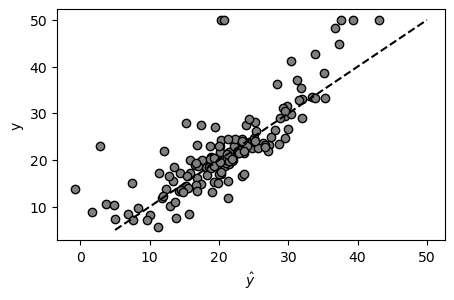

In [7]:
# mostra os resultados
plt.figure(figsize=(5,3))
l = plt.plot(y_pred, y_test, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
# mostra a linha x = y
plt.plot([min(y),max(y)],[min(y),max(y)],
         color = 'black', linestyle='--')
plt.ylabel("y", fontsize=10)
plt.xlabel(r"$\hat{y}$", fontsize=10)
plt.show(True)